In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\bsrik\OneDrive\Desktop\CustomerDNA\data\Online Retail.xlsx")

print(df.shape)

display(df.head())

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Create working copy
dfc = df.copy()

# Remove missing customer IDs
dfc = dfc.dropna(subset=["CustomerID"])

# Remove duplicate records
dfc = dfc.drop_duplicates()

print(dfc.shape)

(401604, 8)


In [4]:
print("Negative/Zero Quantity:", (dfc["Quantity"] <= 0).sum())

print("Negative/Zero Price:", (dfc["UnitPrice"] <= 0).sum())

Negative/Zero Quantity: 8872
Negative/Zero Price: 40


In [5]:
dfc=dfc[dfc["Quantity"]>0]
dfc=dfc[dfc["UnitPrice"]>0]
print(dfc.shape)

(392692, 8)


In [6]:
print((dfc["Quantity"]<=0).sum())

0


In [7]:
dfc["Revenue"]=dfc["UnitPrice"]*dfc["Quantity"]

In [8]:
print("Total Revenue:", round(dfc["Revenue"].sum(),2))

print("Total Customers:", dfc["CustomerID"].nunique())

print("Total Orders:", dfc["InvoiceNo"].nunique())

print("Total Products:", dfc["StockCode"].nunique())

print("Total Countries:", dfc["Country"].nunique())

Total Revenue: 8887208.89
Total Customers: 4338
Total Orders: 18532
Total Products: 3665
Total Countries: 37


In [9]:
country_rev = (
    dfc.groupby("Country")["Revenue"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

country_rev

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [10]:
top_customers = (
    dfc.groupby("CustomerID")["Revenue"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [11]:
cust = dfc.groupby("CustomerID").agg({
    "Revenue":"sum",
    "InvoiceNo":"nunique",
    "InvoiceDate":"max"
})

cust.head()

,Revenue,InvoiceNo,InvoiceDate
CustomerID,,,
12346.0,77183.60,1,2011-01-18 10:01:00
12347.0,4310.00,7,2011-12-07 15:52:00
12348.0,1797.24,4,2011-09-25 13:13:00
12349.0,1757.55,1,2011-11-21 09:51:00
12350.0,334.40,1,2011-02-02 16:01:00


In [12]:
cust.columns = [
    "TotalRevenue",
    "TotalOrders",
    "LastPurchaseDate"
]

cust.head()

,TotalRevenue,TotalOrders,LastPurchaseDate
CustomerID,,,
12346.0,77183.60,1,2011-01-18 10:01:00
12347.0,4310.00,7,2011-12-07 15:52:00
12348.0,1797.24,4,2011-09-25 13:13:00
12349.0,1757.55,1,2011-11-21 09:51:00
12350.0,334.40,1,2011-02-02 16:01:00


In [13]:
snapshot_date = dfc["InvoiceDate"].max()

print(snapshot_date)

2011-12-09 12:50:00


In [14]:
cust["Recency"] = (
    snapshot_date - cust["LastPurchaseDate"]
).dt.days

cust.head()

,TotalRevenue,TotalOrders,LastPurchaseDate,Recency
CustomerID,,,,
12346.0,77183.60,1,2011-01-18 10:01:00,325
12347.0,4310.00,7,2011-12-07 15:52:00,1
12348.0,1797.24,4,2011-09-25 13:13:00,74
12349.0,1757.55,1,2011-11-21 09:51:00,18
12350.0,334.40,1,2011-02-02 16:01:00,309


In [15]:
cust["Frequency"] = cust["TotalOrders"]

cust["Monetary"] = cust["TotalRevenue"]

In [16]:
cust[["Recency","Frequency","Monetary"]].head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [17]:
cust[["Recency","Frequency","Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


In [18]:
cust["R_Score"] = pd.qcut(
    cust["Recency"],
    4,
    labels=[4,3,2,1]
)

cust["F_Score"] = pd.qcut(
    cust["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

cust["M_Score"] = pd.qcut(
    cust["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [19]:
cust["RFM_Score"] = (
    cust["R_Score"].astype(str) +
    cust["F_Score"].astype(str) +
    cust["M_Score"].astype(str)
)

cust.head()

,TotalRevenue,TotalOrders,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,,,
12346.0,77183.60,1,2011-01-18 10:01:00,325,1,77183.60,1,1,4,114
12347.0,4310.00,7,2011-12-07 15:52:00,1,7,4310.00,4,4,4,444
12348.0,1797.24,4,2011-09-25 13:13:00,74,4,1797.24,2,3,4,234
12349.0,1757.55,1,2011-11-21 09:51:00,18,1,1757.55,3,1,4,314
12350.0,334.40,1,2011-02-02 16:01:00,309,1,334.40,1,1,2,112


In [20]:
snapshot_date = dfc["InvoiceDate"].max()

cust["Recency"] = (
    snapshot_date - cust["LastPurchaseDate"]
).dt.days

cust["Frequency"] = cust["TotalOrders"]

cust["Monetary"] = cust["TotalRevenue"]

cust[["Recency","Frequency","Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


In [21]:
cust["R_Score"] = pd.qcut(
    cust["Recency"],
    4,
    labels=[4,3,2,1]
)

cust["F_Score"] = pd.qcut(
    cust["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

cust["M_Score"] = pd.qcut(
    cust["Monetary"],
    4,
    labels=[1,2,3,4]
)

cust["RFM_Score"] = (
    cust["R_Score"].astype(str) +
    cust["F_Score"].astype(str) +
    cust["M_Score"].astype(str)
)

cust[[
    "Recency",
    "Frequency",
    "Monetary",
    "RFM_Score"
]].head()

,Recency,Frequency,Monetary,RFM_Score
CustomerID,,,,
12346.0,325,1,77183.60,114
12347.0,1,7,4310.00,444
12348.0,74,4,1797.24,234
12349.0,18,1,1757.55,314
12350.0,309,1,334.40,112


In [22]:
def segment_customer(row):
    
    if row["RFM_Score"] == "444":
        return "Champions"
    
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_Score"] >= 3:
        return "Potential Loyalists"
    
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    
    else:
        return "Lost Customers"

cust["Segment"] = cust.apply(segment_customer, axis=1)

In [23]:
cust["Segment"].value_counts()

Segment
Lost Customers         1504
Loyal Customers        1034
Potential Loyalists     665
At Risk                 646
Champions               489
Name: count, dtype: int64

In [24]:
cust.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

Segment
Champions              4424373.610
Loyal Customers        2159756.491
At Risk                1038214.361
Lost Customers          765260.062
Potential Loyalists     499604.370
Name: Monetary, dtype: float64

In [25]:
import os

os.makedirs("images", exist_ok=True)

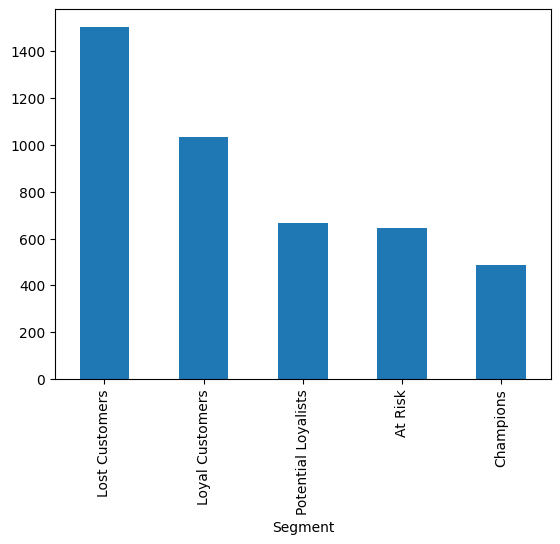

In [26]:
import matplotlib.pyplot as plt

cust["Segment"].value_counts().plot(kind="bar")

plt.savefig("segment_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
import os

os.listdir("images")

[]

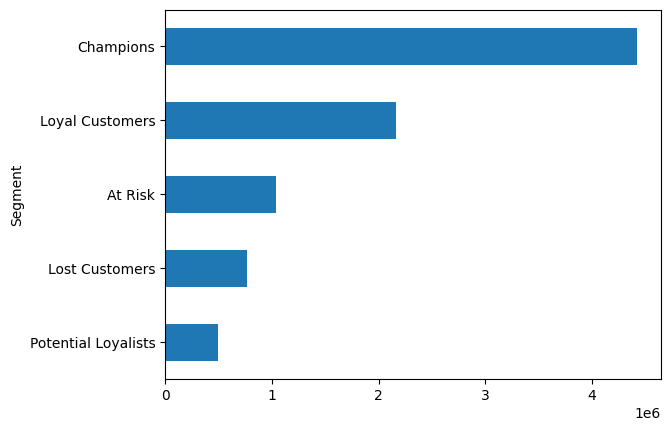

In [33]:
cust.groupby("Segment")["Monetary"]\
    .sum()\
    .sort_values()\
    .plot(kind="barh")
plt.savefig("segment_Monetary.png", dpi=300, bbox_inches="tight")

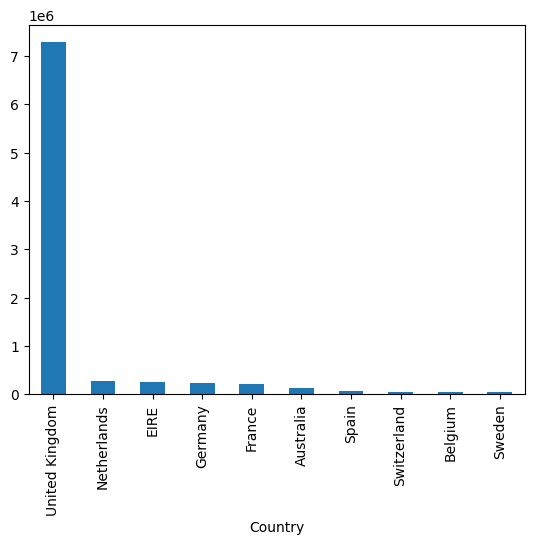

In [34]:
country_rev.head(10).plot(kind="bar")

plt.savefig("country_rev.png", dpi=300, bbox_inches="tight")

In [31]:
dfc.to_csv("customerdna_clean.csv", index=False)

In [35]:
import os

print(os.getcwd())

c:\Users\bsrik\OneDrive\Desktop\CustomerDNA


In [36]:
os.listdir()

['customerdna_clean.csv', 'data', 'images', 'jupyter Note book.ipynb']

In [37]:
os.getcwd()

'c:\\Users\\bsrik\\OneDrive\\Desktop\\CustomerDNA'